In [2]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [3]:
dataroot = "/Users/haoming/Desktop/ML Basics/football_player_generator/football_images"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 128

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 200

# Size of feature maps in generator
ngf = 128

# Size of feature maps in discriminator
ndf = 128

# Number of training epochs
num_epochs = 5

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 0

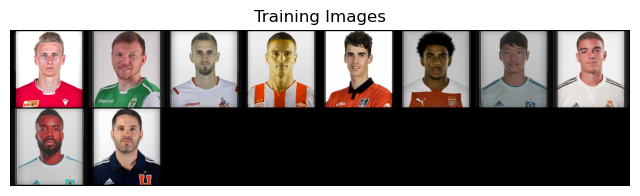

In [4]:
dataset = dset.ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.RandomHorizontalFlip(),
                               transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [5]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.model = nn.Sequential(
            # input is Z, going into a transposed convolution
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),  # (nz, 1, 1) -> (ngf*8, 4, 4)
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),  # (ngf*8, 4, 4) -> (ngf*4, 8, 8)
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),  # (ngf*4, 8, 8) -> (ngf*2, 16, 16)
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),  # (ngf*2, 16, 16) -> (ngf, 32, 32)
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),  # (ngf, 32, 32) -> (nc, 64, 64)
            nn.BatchNorm2d(nc),
            nn.ReLU(True),
            nn.ConvTranspose2d(nc, nc, 4, 2, 1, bias=False),  # (nc, 64, 64) -> (nc, 128, 128)
            nn.Tanh()  # Output size: (nc, 128, 128)
        )
        
    def forward(self, input):
        return self.model(input)



In [7]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.model = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 2, 0, bias=False),
            nn.Conv2d(1, 1, 4, 2, 1, bias=False), 
            nn.Sigmoid()
        )
    def forward(self, input):
        output = self.model(input)
        # Flatten the output to shape [batch_size, 1]
        output = output.view(-1, 1)
        return output



In [8]:
# Create the generator
netG = Generator(ngpu).to(device)
# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)
# Create the Discriminator


Generator(
  (model): Sequential(
    (0): ConvTranspose2d(200, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchN

In [9]:
netD = Discriminator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(1024, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (12): Conv2d(1, 1, kernel_size=(4, 4), stride=

In [10]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(128, nz, 1, 1, device=device)
real_label = 1.
fake_label = 0.
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [11]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(100):
    if epoch%10 == 0:
        torch.save(netG.state_dict(), 'netG_epoch_{}.pth'.format(epoch))
        torch.save(netD.state_dict(), 'netD_epoch_{}.pth'.format(epoch))
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/5][0/68]	Loss_D: 1.4059	Loss_G: 0.9249	D(x): 0.4969	D(G(z)): 0.5061 / 0.3970
[0/5][50/68]	Loss_D: 0.0226	Loss_G: 5.2567	D(x): 0.9970	D(G(z)): 0.0194 / 0.0052
[1/5][0/68]	Loss_D: 0.0137	Loss_G: 5.5081	D(x): 0.9949	D(G(z)): 0.0084 / 0.0041
[1/5][50/68]	Loss_D: 0.0035	Loss_G: 6.3033	D(x): 0.9992	D(G(z)): 0.0027 / 0.0018
[2/5][0/68]	Loss_D: 0.0031	Loss_G: 6.4437	D(x): 0.9995	D(G(z)): 0.0026 / 0.0016
[2/5][50/68]	Loss_D: 0.0037	Loss_G: 6.7281	D(x): 0.9996	D(G(z)): 0.0033 / 0.0012
[3/5][0/68]	Loss_D: 0.0018	Loss_G: 7.0493	D(x): 0.9997	D(G(z)): 0.0015 / 0.0009
[3/5][50/68]	Loss_D: 0.0013	Loss_G: 7.1472	D(x): 0.9997	D(G(z)): 0.0010 / 0.0008
[4/5][0/68]	Loss_D: 0.0010	Loss_G: 7.3070	D(x): 0.9998	D(G(z)): 0.0008 / 0.0007
[4/5][50/68]	Loss_D: 0.0010	Loss_G: 7.6646	D(x): 0.9998	D(G(z)): 0.0008 / 0.0005
[5/5][0/68]	Loss_D: 0.1590	Loss_G: 3.5132	D(x): 0.9365	D(G(z)): 0.0850 / 0.0300
[5/5][50/68]	Loss_D: 0.0093	Loss_G: 6.2130	D(x): 0.9964	D(G(z)): 0.0057 / 0.0020
[6/5][0/

KeyboardInterrupt: 

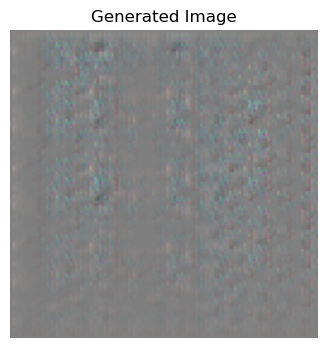

In [13]:
# Generate a single random noise vector
fixed_noise = torch.randn(1, nz, 1, 1, device=device)  # Batch size is 1

with torch.no_grad():
    fake_image = netG(fixed_noise).detach().cpu()  # Generate a single fake image

# Remove the batch dimension and convert to NumPy
fake_image = fake_image.squeeze(0)  # Remove batch dimension
np_image = fake_image.numpy().transpose((1, 2, 0))

# Plot the image
plt.figure(figsize=(4, 4))  # Adjust figure size as needed
plt.axis("off")
plt.title("Generated Image")
plt.imshow((np_image * 0.5) + 0.5)  # Denormalize the image (assuming normalization was [-1, 1])
plt.show()

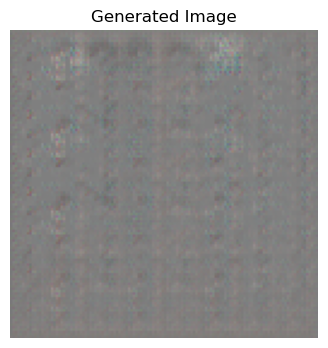

In [27]:
netG.load_state_dict(torch.load('netG_epoch_10.pth'))
# Generate a single random noise vector
fixed_noise = torch.randn(1, nz, 1, 1, device=device)  # Batch size is 1

with torch.no_grad():
    fake_image = netG(fixed_noise).detach().cpu()  # Generate a single fake image

# Remove the batch dimension and convert to NumPy
fake_image = fake_image.squeeze(0)  # Remove batch dimension
np_image = fake_image.numpy().transpose((1, 2, 0))

# Plot the image
plt.figure(figsize=(4, 4))  # Adjust figure size as needed
plt.axis("off")
plt.title("Generated Image")
plt.imshow((np_image * 0.5) + 0.5)  # Denormalize the image (assuming normalization was [-1, 1])
plt.show()